## 深層学習の実習

### 訓練データとテストデータそれぞれの画像ファイルを読み込む

#### `image_dataset_from_directory()` で読み込む

In [1]:
# 訓練データとテストデータの画像を読み込む
# （サイズは縦横224pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "nagaoka_gis/train",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "nagaoka_gis/test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 20 files belonging to 2 classes.
Found 6 files belonging to 2 classes.


#### データを確認する

In [2]:
# データの詳細を表示する
list(train_dataset.as_numpy_iterator())[0]

(array([[[[ 49.52041  ,  72.80612  ,  52.234695 ],
          [ 48.390305 ,  72.390305 ,  48.390305 ],
          [ 47.176014 ,  73.74745  ,  44.27806  ],
          ...,
          [ 32.285664 ,  58.285664 ,  33.285664 ],
          [ 52.196358 ,  81.19636  ,  53.196358 ],
          [ 47.992325 ,  76.992325 ,  48.992325 ]],
 
         [[ 44.5      ,  67.78571  ,  47.214287 ],
          [ 46.571426 ,  70.57143  ,  46.571426 ],
          [ 49.795918 ,  73.79591  ,  49.836735 ],
          ...,
          [ 38.091988 ,  64.09199  ,  39.091988 ],
          [ 38.03796  ,  63.520103 ,  40.073673 ],
          [ 55.255062 ,  80.737206 ,  57.290775 ]],
 
         [[ 49.492348 ,  72.77806  ,  52.206635 ],
          [ 49.61479  ,  73.6148   ,  49.61479  ],
          [ 42.288265 ,  63.632652 ,  45.086735 ],
          ...,
          [ 43.20148  ,  69.201485 ,  44.20148  ],
          [ 47.474518 ,  70.47452  ,  50.474518 ],
          [ 26.393103 ,  49.393105 ,  29.393103 ]],
 
         ...,
 
         [[ 

In [3]:
# 分類名（no／yes）をリストとして格納する
class_names = train_dataset.class_names
class_names

['no', 'yes']

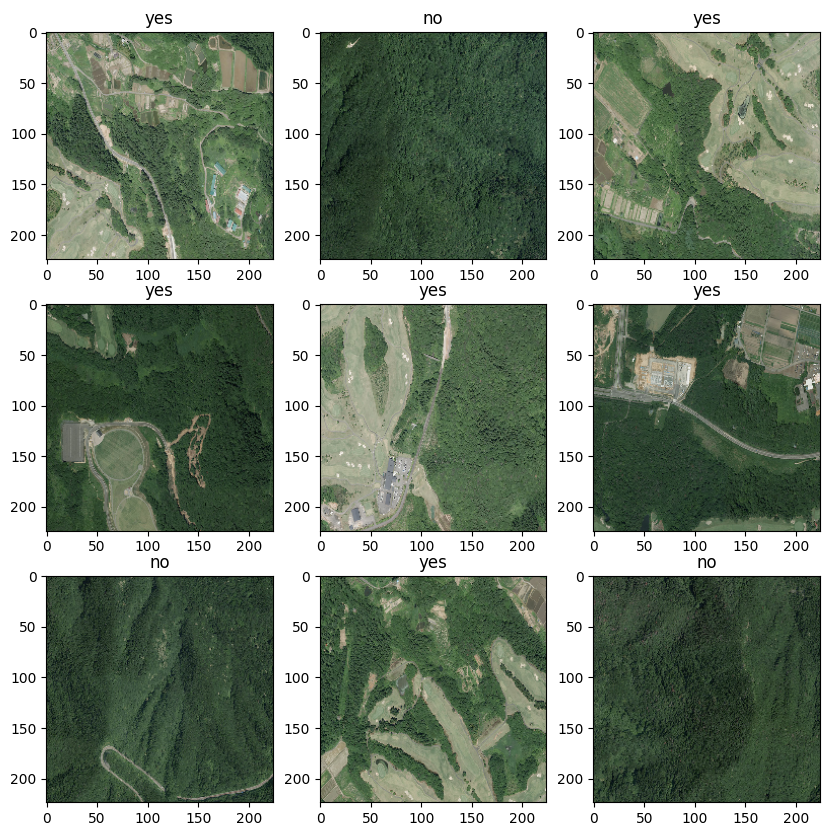

In [6]:
# 訓練データの一部を表示して確認
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

### データの水増しを行なう

In [7]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label

In [8]:
# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

In [9]:
# 水増ししたデータを訓練データに追加する
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

In [10]:
# データをシャッフルする
train_dataset = train_dataset.shuffle(32)

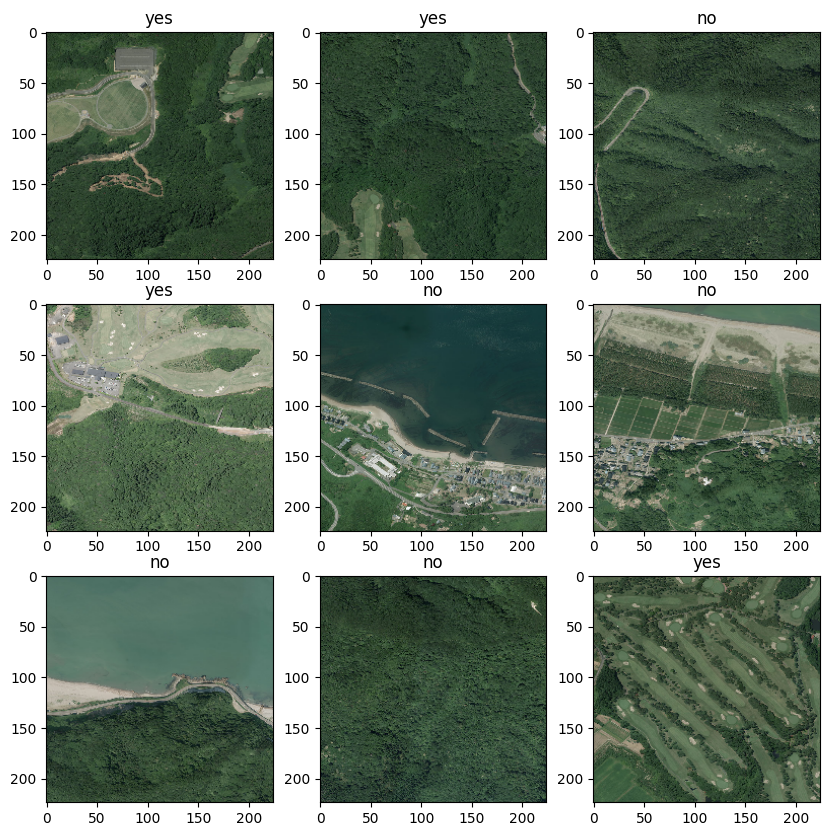

In [11]:
# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

### モデルを作って学習する

#### MobileNetV2の学習済みモデルを読み込む

In [12]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### 出力層を作成する

In [13]:
# Dense層を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

#### モデルを完成させる

In [14]:
# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])

In [15]:
# modelをcompileする
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])

In [16]:
# modelに学習させる
model.fit(train_dataset, epochs=20)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 247ms/step - accuracy: 0.7000 - loss: 0.5751
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - accuracy: 0.8667 - loss: 0.3706
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step - accuracy: 0.9333 - loss: 0.2534
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - accuracy: 0.9667 - loss: 0.1801
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 237ms/step - accuracy: 0.9917 - loss: 0.1359
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - accuracy: 0.9917 - loss: 0.1065
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 263ms/step - accuracy: 0.9917 - loss: 0.0864
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - accuracy: 1.0000 - loss: 0.0725
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 237ms/step - accuracy: 1.0000 - loss: 0.0620
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 261ms/step - accuracy: 1.0000 - loss: 0.0541
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 234ms/step - accuracy: 1.0000 - loss: 0.0478
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step - accuracy: 1.0000 - lo

In [17]:
# テストデータで分類を実行する
pred_data = model.predict(test_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step


In [18]:
# 分類した結果を確認する
pred_data

array([[0.19682495],
       [0.42469254],
       [0.06024167],
       [0.9942968 ],
       [0.52538514],
       [0.98985547]], dtype=float32)

In [19]:
# evaluate()でモデルの性能を評価する
model.evaluate(test_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 982ms/step - accuracy: 1.0000 - loss: 0.2490


[0.24895089864730835, 1.0]